# EEG Analysis 

In [4]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import mne

mne.set_log_level('WARNING')
%matplotlib inline

print(f'MNE version: {mne.__version__}')

MNE version: 1.12.0


Cargamos los 4 archivos `.fif` de cada sujeto :
- `loc_epo.fif`
- `locstim_epo.fif` 
- `main_epo.fif` 
- `mainstim_epo.fif` 

In [5]:
data_dir = '/Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EEG/'

# sujetos disponibles 
subjs_list = sorted([
    d for d in os.listdir(data_dir)
    if os.path.isdir(os.path.join(data_dir, d)) and d.startswith('s')
])
print(f'Sujetos encontrados ({len(subjs_list)}): {subjs_list}')

Sujetos encontrados (28): ['s01', 's02', 's03', 's04', 's05', 's06', 's07', 's08', 's09', 's0x', 's10', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's18', 's19', 's20', 's21', 's22', 's23', 's24', 's25', 's26', 's27']


In [6]:
# creamos listas vacías donde iremos guardando los datos de cada sujeto a medida que los cargamos

all_main_epochs   = []   
all_loc_epochs    = []  
all_locstim_epochs  = [] 
all_mainstim_epochs = [] 

all_main_rawdata    = []  
all_loc_rawdata     = []
all_locstim_rawdata = []
all_mainstim_rawdata = []

subjs_ok = []  # sujetos que se cargan correctamente

# para cada sujeto construimos las rutas completas a sus 4 archivos
for subject_id in subjs_list:
    subj_path = os.path.join(data_dir, subject_id)
    files = {
        'main':     os.path.join(subj_path, 'main_epo.fif'),
        'loc':      os.path.join(subj_path, 'loc_epo.fif'),
        'locstim':  os.path.join(subj_path, 'locstim_epo.fif'),
        'mainstim': os.path.join(subj_path, 'mainstim_epo.fif'),
    }
    
    # comprobamos que existen todos los archivos
    if not all(os.path.exists(f) for f in files.values()):
        print(f'{subject_id}: faltan archivos, se omite')
        continue
    
    try:
        main     = mne.read_epochs(files['main'],     preload=True, verbose=False)
        loc      = mne.read_epochs(files['loc'],      preload=True, verbose=False)
        locstim  = mne.read_epochs(files['locstim'],  preload=True, verbose=False)
        mainstim = mne.read_epochs(files['mainstim'], preload=True, verbose=False)
        
        all_main_epochs.append(main)
        all_loc_epochs.append(loc)
        all_locstim_epochs.append(locstim)
        all_mainstim_epochs.append(mainstim)
        
        all_main_rawdata.append({
            'epoch_dat': main.get_data(), 'metadata': main.metadata})
        all_loc_rawdata.append({
            'epoch_dat': loc.get_data(),  'metadata': loc.metadata})
        all_locstim_rawdata.append({
            'epoch_dat': locstim.get_data(), 'metadata': locstim.metadata})
        all_mainstim_rawdata.append({
            'epoch_dat': mainstim.get_data(), 'metadata': mainstim.metadata})
        
        subjs_ok.append(subject_id)
        print(f'{subject_id} cargado — main: {main.get_data().shape}, '
              f'loc: {loc.get_data().shape}, '
              f'locstim: {locstim.get_data().shape}')
    except Exception as e:
        print(f'{subject_id}: error al cargar → {e}')

nSubj = len(subjs_ok)
print(f'\ntotal sujetos cargados: {nSubj}')

# (número de trials,  número de canales,  número de timepoints)


s01 cargado — main: (250, 32, 2876), loc: (150, 32, 2876), locstim: (954, 32, 201)
s02 cargado — main: (261, 32, 2876), loc: (156, 32, 2876), locstim: (913, 32, 201)
s03 cargado — main: (256, 32, 2876), loc: (146, 32, 2876), locstim: (935, 32, 201)
s04 cargado — main: (236, 32, 2876), loc: (121, 32, 2876), locstim: (795, 32, 201)
s05 cargado — main: (243, 32, 2876), loc: (150, 32, 2876), locstim: (920, 32, 201)
s06: faltan archivos, se omite
s07 cargado — main: (249, 32, 2876), loc: (156, 32, 2876), locstim: (859, 32, 201)
s08 cargado — main: (247, 32, 2876), loc: (143, 32, 2876), locstim: (896, 32, 201)
s09 cargado — main: (193, 32, 2876), loc: (153, 32, 2876), locstim: (936, 32, 201)
s0x: faltan archivos, se omite
s10 cargado — main: (250, 32, 2876), loc: (153, 32, 2876), locstim: (787, 32, 201)
s11 cargado — main: (251, 32, 2876), loc: (147, 32, 2876), locstim: (699, 32, 201)
s12 cargado — main: (252, 32, 2876), loc: (141, 32, 2876), locstim: (792, 32, 201)
s13 cargado — main: (253,

## Grand Average
Ploteamos la media de todos los trials de todos los sujetos.
Las líneas verticales indican:
- Azul : inicio del trial (t=0)
- Verde : onset de cada uno de los 6 estímulos
- Rojo : inicio y fin de la secuencia de estímulos

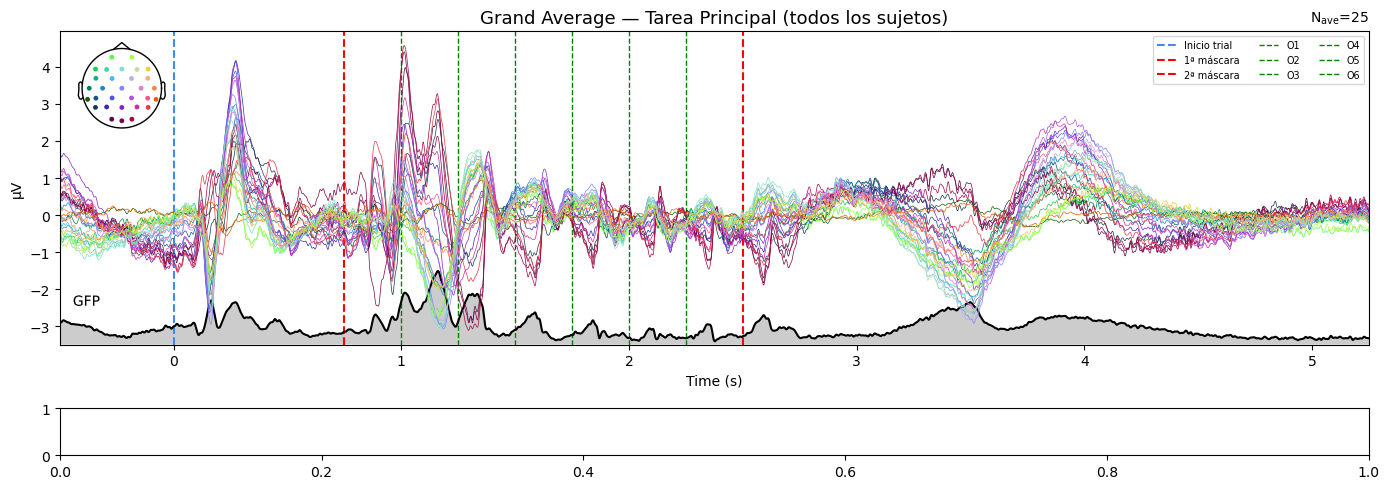

In [5]:

main_evokeds = [ep.average() for ep in all_main_epochs] # para cada sujeto calculamos la media de todos sus trials = ERP
main_gaverage = mne.grand_average(main_evokeds) # promedia los ERPs de los 25 sujetos entre si = GRAND AVERAGE

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 5),
                         gridspec_kw=dict(height_ratios=[5, 0.75]))

main_gaverage.plot(axes=axes[0], spatial_colors=True, gfp=True, show=False)
axes[0].set_title('Grand Average — Tarea Principal (todos los sujetos)', fontsize=13)

# añadimos las lineas temporales: onset de cada estímulo (máscara + 6 estímulos + máscara)
# máscara t=0.75s, estímulos cada 0.25s
axes[0].axvline(0,                    color='#4488EE', ls='--', lw=1.5, label='Inicio trial')
axes[0].axvline(0.75,                 color='red',     ls='--', lw=1.5, label='1ª máscara')
axes[0].axvline(0.75 + 0.25 * 7,     color='red',     ls='--', lw=1.5, label='2ª máscara')
for istim in range(6):
    t = 0.75 + 0.25 * (istim + 1)
    axes[0].axvline(t, color='green', ls='--', lw=1, 
                    label=f'O{istim+1}' if istim == 0 else f'O{istim+1}')

axes[0].legend(loc='upper right', fontsize=7, ncol=3)
plt.tight_layout()
plt.show()

## Canal occipital (Oz) separado por nrep

Queremos ver si la amplitud de la respuesta occipital va **disminuyendo** a medida que el trial se repite (nrep 0 → 1 → 2) que seria la prueba del sesgo de confirmación a nivel neural

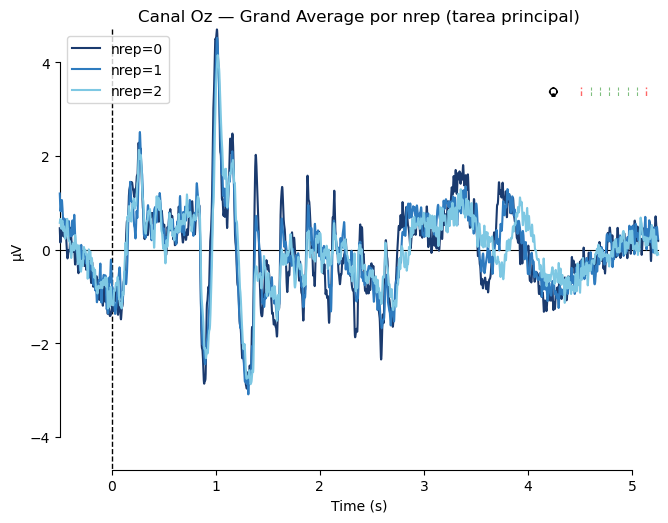

In [6]:
# grand average por nrep 
nreps = [0, 1, 2]
colors_nrep = ['#1a3a6e', '#2e7bbf', '#7ec8e3']  # azul oscuro → azul clarito

# para cada nrep, calculamos la media de cada sujeto y luego el grand average
# es decir, para cada nrep, para cada sujeto, coge los trials correspondientes a ese nrep, calcula su media (ERP) y luego promedia entre sujetos (grand average)
rep_gaverage = []
for irep in nreps:
    evoks_irep = []
    for isubj in range(nSubj):
        epoch = all_main_epochs[isubj]
        mdata = epoch.metadata.copy().reset_index(drop=True)
        sel_idx = mdata[mdata['nrep'] == irep].index
        if len(sel_idx) > 0:
            evoks_irep.append(epoch[sel_idx].average())
    if evoks_irep:
        rep_gaverage.append(mne.grand_average(evoks_irep))
    else:
        rep_gaverage.append(None)

# plot_compare_evokeds es una funcion de MNE que plotea varios ERPs juntos para compararlos. 
# le pasamos los 3 grand averages y le decimos picks=['Oz'] para que solo muestre el canal Oz (el occipital central, el mas relevante para ver la respuesta visual)
evokeds_dict = {
    f'nrep={irep}': rep_gaverage[irep]
    for irep in nreps if rep_gaverage[irep] is not None
}

fig = mne.viz.plot_compare_evokeds(
    evokeds_dict,
    picks=['Oz'],
    colors=colors_nrep[:len(evokeds_dict)],
    title='Canal Oz — Grand Average por nrep (tarea principal)',
    show=False
)

# Añadimos líneas de onset de estímulos
ax = plt.gca()
ax.axvline(0.75,             color='red',   ls='--', lw=1, alpha=0.6)
ax.axvline(0.75 + 0.25 * 7, color='red',   ls='--', lw=1, alpha=0.6)
for istim in range(6):
    ax.axvline(0.75 + 0.25 * (istim + 1), color='green', ls='--', lw=0.8, alpha=0.5)
plt.tight_layout()
plt.show()

## Grand Average del localizador

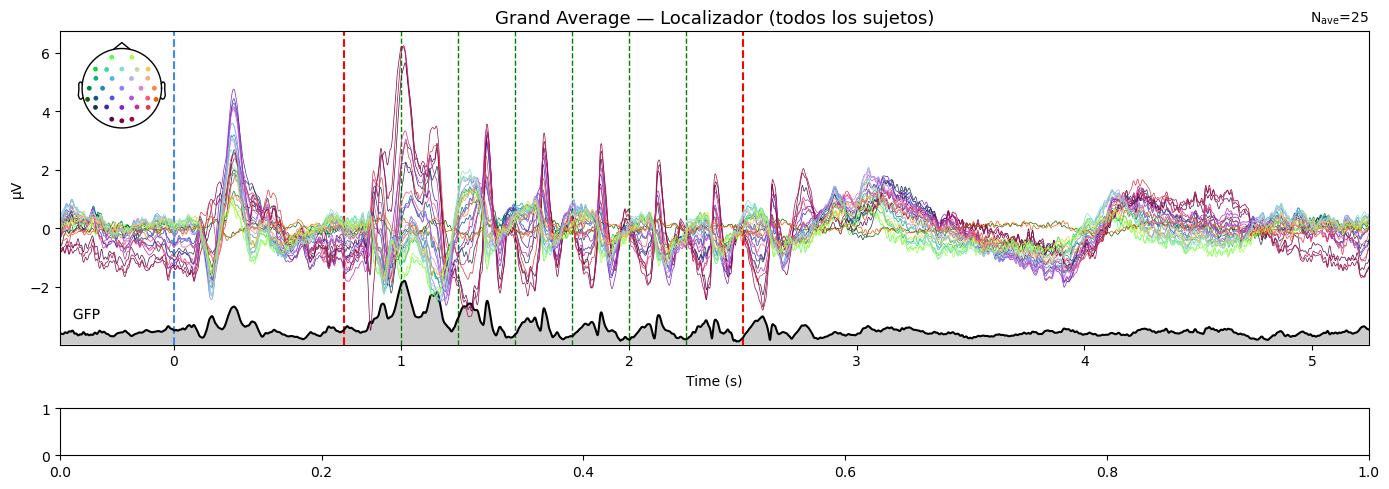

In [7]:
# grand average localizador 
loc_evokeds  = [ep.average() for ep in all_loc_epochs]
loc_gaverage = mne.grand_average(loc_evokeds)

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 5),
                         gridspec_kw=dict(height_ratios=[5, 0.75]))

loc_gaverage.plot(axes=axes[0], spatial_colors=True, gfp=True, show=False)
axes[0].set_title('Grand Average — Localizador (todos los sujetos)', fontsize=13)

axes[0].axvline(0,                color='#4488EE', ls='--', lw=1.5)
axes[0].axvline(0.75,             color='red',     ls='--', lw=1.5)
axes[0].axvline(0.75 + 0.25 * 7, color='red',     ls='--', lw=1.5)
for istim in range(6):
    axes[0].axvline(0.75 + 0.25 * (istim + 1), color='green', ls='--', lw=1)

plt.tight_layout()
plt.show()

## Piquitos del locstim
cada "trial" en `locstim_epo` es un estímulo individual del localizador 
--> por ejemplo s01 tiene 954 de estos trials (≈ 150 trials × 6 estímulos)

la ventana es muy pequeña (−0.1s a +0.3s)

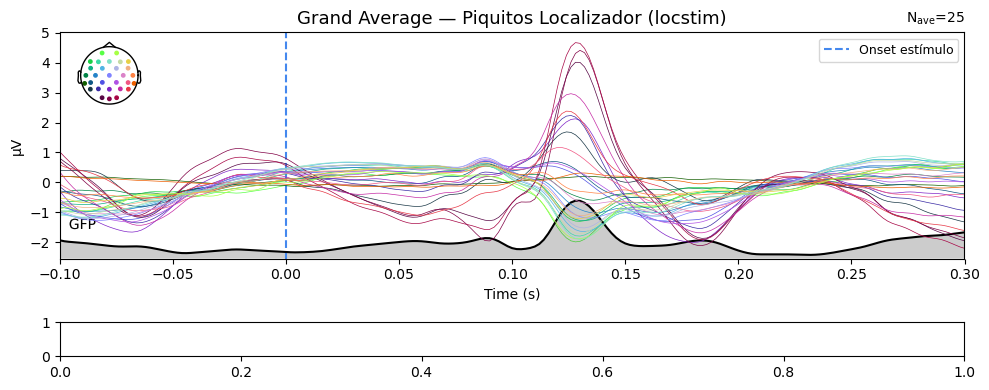

In [8]:
# grand average locstim (piquitos del localizador) 
locstim_evokeds  = [ep.average() for ep in all_locstim_epochs]
locstim_gaverage = mne.grand_average(locstim_evokeds)

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 4),
                         gridspec_kw=dict(height_ratios=[5, 0.75]))

locstim_gaverage.plot(axes=axes[0], spatial_colors=True, gfp=True, show=False)
axes[0].set_title('Grand Average — Piquitos Localizador (locstim)', fontsize=13)
axes[0].axvline(0, color='#4488EE', ls='--', lw=1.5, label='Onset estímulo')
axes[0].legend(fontsize=9)

plt.tight_layout()
plt.show()

## RESUMEN

In [9]:
header = f"{'Sujeto':<8} {'main':>22} {'loc':>22} {'locstim':>22} {'mainstim':>22}"
print(header)
print('-' * 80)
for i, subj in enumerate(subjs_ok):
    sh_main     = all_main_rawdata[i]['epoch_dat'].shape
    sh_loc      = all_loc_rawdata[i]['epoch_dat'].shape
    sh_locstim  = all_locstim_rawdata[i]['epoch_dat'].shape
    sh_mainstim = all_mainstim_rawdata[i]['epoch_dat'].shape
    print(f"{subj:<8} {str(sh_main):>22} {str(sh_loc):>22} {str(sh_locstim):>22} {str(sh_mainstim):>22}")

print(f"\nDimensiones: (trials x canales x timepoints)")
print(f"Sfreq: {all_main_epochs[0].info['sfreq']} Hz")
print(f"Canales: {len(all_main_epochs[0].ch_names)}")
print(f"Ventana main/loc: {all_main_epochs[0].tmin:.2f}s -> {all_main_epochs[0].tmax:.2f}s")
print(f"Ventana locstim:  {all_locstim_epochs[0].tmin:.2f}s -> {all_locstim_epochs[0].tmax:.2f}s")

Sujeto                     main                    loc                locstim               mainstim
--------------------------------------------------------------------------------
s01             (250, 32, 2876)        (150, 32, 2876)         (954, 32, 201)        (1563, 32, 201)
s02             (261, 32, 2876)        (156, 32, 2876)         (913, 32, 201)        (261, 32, 2876)
s03             (256, 32, 2876)        (146, 32, 2876)         (935, 32, 201)        (256, 32, 2876)
s04             (236, 32, 2876)        (121, 32, 2876)         (795, 32, 201)        (1415, 32, 201)
s05             (243, 32, 2876)        (150, 32, 2876)         (920, 32, 201)        (243, 32, 2876)
s07             (249, 32, 2876)        (156, 32, 2876)         (859, 32, 201)        (249, 32, 2876)
s08             (247, 32, 2876)        (143, 32, 2876)         (896, 32, 201)        (247, 32, 2876)
s09             (193, 32, 2876)        (153, 32, 2876)         (936, 32, 201)        (193, 32, 2876)
s10       

---
## Clasificador — decoding punto a punto --> FASE 1 : entrenamos y testeamos dentro de main_epo: trials de main → 80% entrenar → 20% testear → score

para cada estímulo Oi y cada timepoint t, queremos entrenar un clasificador que prediga
la orientación del estímulo a partir de la actividad de los 32 canales en ese instante

### funciones auxiliares 

In [7]:
# definimos funciones auxiliares para el decoding que usara el clasificador mas adelante

import numpy as np
from sklearn.svm import LinearSVR
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.model_selection import StratifiedKFold
import time as tm

# AngularRegression --> CLASIFICADOR ADAPTADO A ORIENTACIONES CIRCULARES
# usamos un clasificador que aprende a predecir un numero a partir de features 
# PROBLEMA --> las orientaciones son circulares, es decir, 0° y 180° son iguales en gratings, entonces no podemos predecir el ángulo directamente con una regresión lineal porque el modelo no entendería que 0° y 180° son lo mismo
# lo que hacemos es convertir el angulo en 2 componentes que si que son lineales --> cos(2θ) y sin(2θ) por separado
# y luego los combinamoa para recuperar el ángulo origina
class AngularRegression(BaseEstimator, RegressorMixin):
    def __init__(self, clf=None):
        self.clf = clf if clf is not None else LinearSVR()

    def fit(self, X, y):
        # y son orientaciones en radianes
        # multiplicamos por 2 para que 0° y 180° sean equivalentes
        self.clf_cos = clone(self.clf)
        self.clf_sin = clone(self.clf)
        self.clf_cos.fit(X, np.cos(2 * y))
        self.clf_sin.fit(X, np.sin(2 * y))
        return self

    def predict(self, X):
        cos_pred = self.clf_cos.predict(X)
        sin_pred = self.clf_sin.predict(X)
        # recuperamos el ángulo y dividimos por 2 para volver al espacio original
        return np.arctan2(sin_pred, cos_pred) / 2


# scorer_angle --> mide que tan bien predijo el clasificador la orientacion
# usa la correlación circular: calcula el error entre orientación real y la predicha
# Resultado entre -1 y 1 : 0 = azar, 1 = perfecto
def scorer_angle(y_true, y_pred):
    error = 2 * y_true - 2 * y_pred
    return np.mean(np.cos(error))


#  CreateFolds --> crea 5 folds estratificados: cada fold tiene trials de todas las orientaciones
def create_folds(y_binned, n_folds=5):
   
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    folds = []
    dummy_X = np.zeros(len(y_binned))
    for train_idx, test_idx in skf.split(dummy_X, y_binned):
        folds.append({'train_index': train_idx, 'test_index': test_idx})
    return folds

print('funciones auxiliares definidas: AngularRegression, scorer_angle, create_folds')

funciones auxiliares definidas: AngularRegression, scorer_angle, create_folds


### decoding punto a punto — QUEREMOS SABER EN QUE MOMENTO DEL TRIAL EL CEREBRO ESTA CODIFICANDO LA ORIENTACION DE CADA ESTIMULO

para saber eso, necesitamos un clasificador que, mirando la actividad de los 32 canales en un instante concreto, sea capaz de adivinar QUE orientacion se estaba presentando


── Sujeto s01 (1/25) ──
  O1 ✓  O2 ✓  O3 ✓  O4 ✓  O5 ✓  O6 ✓  → 3.9 min transcurridos

── Sujeto s02 (2/25) ──
  O1 ✓  O2 ✓  O3 ✓  O4 ✓  O5 ✓  O6 ✓  → 8.4 min transcurridos

── Sujeto s03 (3/25) ──
  O1 ✓  O2 ✓  O3 ✓  O4 ✓  O5 ✓  O6 ✓  → 12.4 min transcurridos

── Sujeto s04 (4/25) ──
  O1 ✓  O2 ✓  O3 ✓  O4 ✓  O5 ✓  O6 ✓  → 16.4 min transcurridos

── Sujeto s05 (5/25) ──
  O1 ✓  O2 ✓  O3 ✓  O4 ✓  O5 ✓  O6 ✓  → 20.3 min transcurridos

── Sujeto s07 (6/25) ──
  O1 ✓  O2 ✓  O3 ✓  O4 ✓  O5 ✓  O6 ✓  → 24.5 min transcurridos

── Sujeto s08 (7/25) ──
  O1 ✓  O2 ✓  O3 ✓  O4 ✓  O5 ✓  O6 ✓  → 28.5 min transcurridos

── Sujeto s09 (8/25) ──
  O1 ✓  O2 ✓  O3 ✓  O4 ✓  O5 ✓  O6 ✓  → 32.1 min transcurridos

── Sujeto s10 (9/25) ──
  O1 ✓  O2 ✓  O3 ✓  O4 ✓  O5 ✓  O6 ✓  → 36.1 min transcurridos

── Sujeto s11 (10/25) ──
  O1 ✓  O2 ✓  O3 ✓  O4 ✓  O5 ✓  O6 ✓  → 45.4 min transcurridos

── Sujeto s12 (11/25) ──
  O1 ✓  O2 ✓  O3 ✓  O4 ✓  O5 ✓  O6 ✓  → 48.5 min transcurridos

── Sujeto s13 (12/25) ──
  O1 ✓

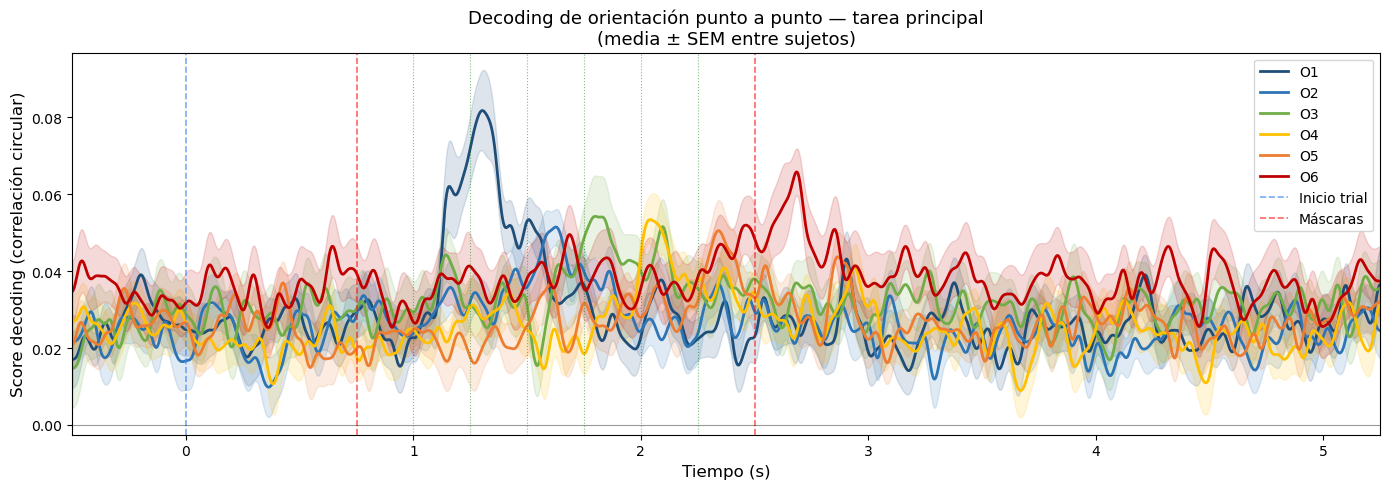

In [ ]:
# parameters 
n_folds   = 5
n_stim    = 6
stim_cols = ['o1','o2','o3','o4','o5','o6']
bins_ori  = np.array([0, np.pi/4, np.pi/2, 3*np.pi/4]) # para agrupar las orientaciones en 4 bins (0-45°, 45-90°, 90-135°, 135-180°)
time      = all_main_epochs[0].times # vector de los timepoints
n_time    = len(time) # numero de timepoints (2876)

# la lista donde guardamos los resultados (n_sujetos × n_estímulos × n_timepoints)
scorer_all_subjs = np.zeros((nSubj, n_stim, n_time))
all_preds        = {}  # diccionario donde guardamos las predicciones de cada sujeto y cada estimulo, para reutilizar despues

t_start = tm.time()

# para cada sujeto cogemos sus datos de EEG (Y = un array de shape (n_trials × 32 × 2876)) y su metadata (orientaciones, nrep, etc)
for isubj in range(nSubj):
    print(f'\subj {subjs_ok[isubj]} ({isubj+1}/{nSubj})')
    
    Y = all_main_rawdata[isubj]['epoch_dat']
    metadata = all_main_rawdata[isubj]['metadata'].reset_index(drop=True)
    all_preds[isubj] = {} # diccionario donde guardamos las predicciones de cada sujeto y cada estimulo, para reutilizar despues

    # para cada estímulo (o1, o2, o3, o4, o5, o6) hacemos el decoding punto a punto
    for i_stim, col in enumerate(stim_cols):
        phi        = np.array(metadata[col], dtype=float) # coje la columna de orientaciones del estimulo y todos los trials
        phi_binned = np.digitize(phi % np.pi, bins_ori) # agrupa las orientaciones en 4 bins (0-45°, 45-90°, 90-135°, 135-180°) y convierte cada orientación en un número del 1 al 4 según su bin
        folds      = create_folds(phi_binned, n_folds) # crea los 5 grupos de trials equilibrados para la cross-validation
        preds_all  = np.full((Y.shape[0], n_time), np.nan) # array donde guardamos las predicciones de cada trial y cada timepoint
        clf        = AngularRegression(clf=LinearSVR(max_iter=5000, C=0.1)) # definimos el clasificador que usaremos para predecir la orientación a partir de los datos de EEG. Es ANGULAREGRESION, una regresión lineal adaptada a datos circulares (orientaciones)

        # para cada timepoint
        for it in range(n_time):
            Ytime  = Y[:, :, it] # coge toda la actividad de todos los trials en ese instante exacto
            scaler = StandardScaler().fit(Ytime) # estandariza los datos de EEG para ese timepoint (media 0, desviacion estandar 1) 
            Ytime  = scaler.transform(Ytime)

            # para cada fold
            for fold in folds:
                train_ix = fold['train_index'] # índices de los trials que se usan para entrenar el modelo en ese fold
                test_ix  = fold['test_index'] # índices de los trials que se usan para testear el modelo en ese fold
                clf.fit(Ytime[train_ix], phi[train_ix]) # entrena el clasificador con los datos de EEG de los trials de entrenamiento y sus orientaciones reales
                preds_all[test_ix, it] = clf.predict(Ytime[test_ix]) # se hace la predicción de la orientación para los trials de test y se guarda en el array de predicciones

        # UNA VEZ QUE YA TENEMOS LAS PREDICCIONES, CALCULAMOS EL SCORE DE DECODING PARA CADA TIMEPOINT
        for it in range(n_time): # para cada timepoint
            valid = ~np.isnan(preds_all[:, it]) # selecciona solo los trials para los que el modelo hizo una prediccion
            scorer_all_subjs[isubj, i_stim, it] = scorer_angle(
                phi[valid], preds_all[valid, it]
            ) # comparamos las orientaciones reales (phi) con las predicciones (preds_all) para los trials validos. Devuelve un numero entre 0 y 1 y guardamos ese score de decoding en el array de resultados

        # Guardamos predicciones 
        all_preds[isubj][i_stim] = preds_all.copy()

        print(f'  O{i_stim+1} ✓', end='', flush=True)

    elapsed = (tm.time() - t_start) / 60
    print(f'  → {elapsed:.1f} min transcurridos')

print(f'\ndecoding completado — shape resultado: {scorer_all_subjs.shape}')

# guardar resultados 
import pickle

results = {
    'scorer_all_subjs': scorer_all_subjs,
    'all_preds':        all_preds,
    'time':             time,
    'subjs_ok':         subjs_ok,
    'stim_cols':        stim_cols,
}

save_path = '/Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EEG/decoding_results_main.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(results, f)

print(f'resultados guardados en: {save_path}')

# plot 
from scipy.ndimage import gaussian_filter1d

sigma = 10 # sigma controla cuanto suavizas
scorer_all_subjs_smooth = gaussian_filter1d(scorer_all_subjs, sigma=sigma, axis=2) # suaviza las curvas a lo largo del tiempo, ya que sin esto, las curvas tienen muchos picos de ruido

scorer_mean = np.mean(scorer_all_subjs_smooth, axis=0) # promedia los 25 sujetos para cada estímulo y cada timepoint, obteniendo una curva media de decoding para cada estimulo
scorer_sem  = np.std(scorer_all_subjs_smooth, axis=0) / np.sqrt(nSubj) # calcula el error estandar de la media (SEM) para cada estimulo y cada timepoint, que se usa para dibujar las bandas de error en el plot (media ± SEM)

colors = ['#1f4e79', '#2e75b6', '#70ad47', '#ffc000', '#ed7d31', '#c00000']

fig, ax = plt.subplots(figsize=(14, 5))

for i_stim in range(n_stim):
    mean = scorer_mean[i_stim]
    sem  = scorer_sem[i_stim]
    ax.plot(time, mean, color=colors[i_stim], lw=2, label=f'O{i_stim+1}')
    ax.fill_between(time, mean - sem, mean + sem,
                    color=colors[i_stim], alpha=0.15)

ax.axvline(0,                color='#4488EE', ls='--', lw=1.2, alpha=0.7, label='Inicio trial')
ax.axvline(0.75,             color='red',     ls='--', lw=1.2, alpha=0.6, label='Máscaras')
ax.axvline(0.75 + 0.25 * 7, color='red',     ls='--', lw=1.2, alpha=0.6)
for i_stim in range(6):
    ax.axvline(0.75 + 0.25 * (i_stim + 1), color='green', ls=':', lw=0.8, alpha=0.5)

ax.axhline(0, color='black', ls='-', lw=0.8, alpha=0.4)
ax.set_xlabel('Tiempo (s)', fontsize=12)
ax.set_ylabel('Score decoding (correlación circular)', fontsize=12)
ax.set_title('Decoding de orientación punto a punto — tarea principal\n'
             '(media ± SEM entre sujetos)', fontsize=13)
ax.legend(loc='upper right', fontsize=10)
ax.set_xlim([time[0], time[-1]])
plt.tight_layout()
plt.show()

### Curvas separadas por nrep 

In [ ]:
# decoding por nrep — REUTILIZANDO predicciones para no tener que recalcular todo el decoding desde cero, ya que es lo mismo pero filtrando por nrep
nreps       = [0, 1, 2]
colors_nrep = ['#1a3a6e', '#2e7bbf', '#7ec8e3']

# (n_nreps × n_sujetos × n_estímulos × n_timepoints)
scorer_nrep = np.zeros((len(nreps), nSubj, n_stim, n_time))

# para cada sujeto y para cada estímulo, cogemos phi (orientaciones reales) y preds (las predicciones que ya he calculado)
for isubj in range(nSubj):
    metadata = all_main_rawdata[isubj]['metadata'].reset_index(drop=True)
    
    for i_stim, col in enumerate(stim_cols):
        phi   = np.array(metadata[col], dtype=float)
        preds = all_preds[isubj][i_stim]  # ya calculado, no recalculamos nada
        
        # para cada nrep, filtramos los trials correspondientes a ese nrep y calculamos el score de decoding solo con esos trials, usando las predicciones que ya tenemos
        for i_nrep, nrep in enumerate(nreps):
            idx_nrep = metadata[metadata['nrep'] == nrep].index.tolist() # indices de los trials que corresponden a ese nrep
            if len(idx_nrep) == 0:
                continue
            
            phi_nrep   = phi[idx_nrep] # orientaciones reales de los trials que corresponden a ese nrep
            preds_nrep = preds[idx_nrep] # predicciones del modelo para los trials que corresponden a ese nrep
            
            # para cada timepoint, calculamos el score de decoding solo con los trials de ese nrep
            for it in range(n_time):
                valid = ~np.isnan(preds_nrep[:, it])
                scorer_nrep[i_nrep, isubj, i_stim, it] = scorer_angle(
                    phi_nrep[valid], preds_nrep[valid, it] # calcula el score de decoding para los trials de ese nrep
                )

print('decoding por nrep completado — shape:', scorer_nrep.shape)

✅ Decoding por nrep completado — shape: (3, 25, 6, 2876)


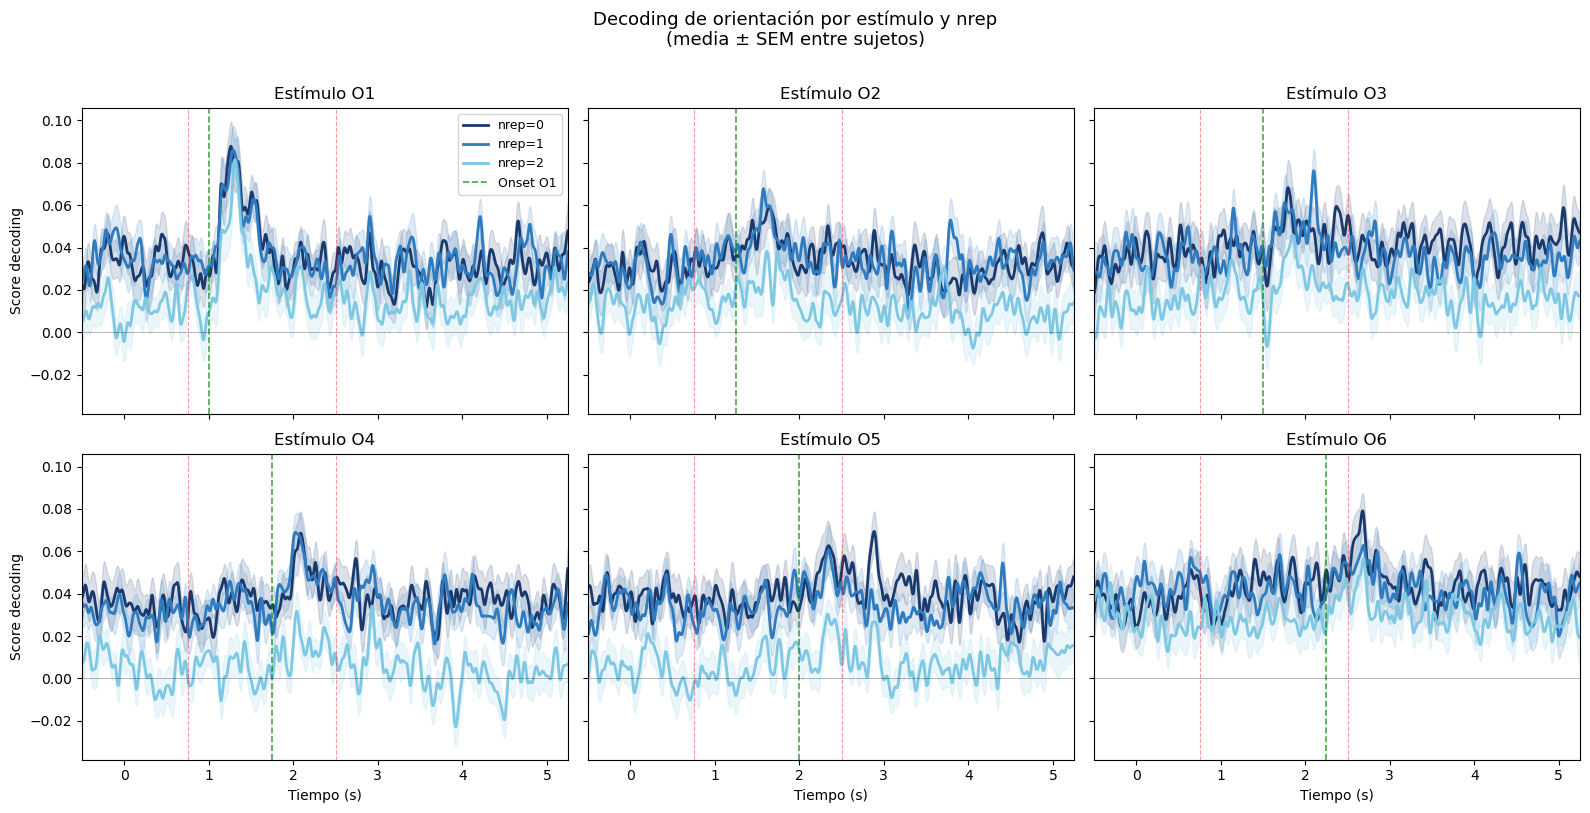

In [ ]:
from scipy.ndimage import gaussian_filter1d

sigma = 10
scorer_nrep_smooth = gaussian_filter1d(scorer_nrep, sigma=sigma, axis=3) # suaviza las curvas a lo largo del tiempo, ya que sin esto, las curvas tienen muchos picos de ruido

nreps       = [0, 1, 2]
colors_nrep = ['#1a3a6e', '#2e7bbf', '#7ec8e3']

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=True)
axes = axes.flatten()

# para cada estimulo
for i_stim in range(n_stim):
    ax = axes[i_stim] # selecciona el subplot correspondiente a ese estímulo
    
    # para cada nrep, calculamos la media y el SEM entre sujetos para ese estímulo y ese nrep
    for i_nrep, nrep in enumerate(nreps):
        mean = np.mean(scorer_nrep_smooth[i_nrep, :, i_stim, :], axis=0) # media entre sujetos para ese nrep, ese estímulo y cada timepoint
        sem  = np.std(scorer_nrep_smooth[i_nrep, :, i_stim, :], axis=0) / np.sqrt(nSubj) # SEM entre sujetos para ese nrep, ese estímulo y cada timepoint
        ax.plot(time, mean, color=colors_nrep[i_nrep], lw=2, label=f'nrep={nrep}')
        ax.fill_between(time, mean - sem, mean + sem,
                        color=colors_nrep[i_nrep], alpha=0.15)
    
    # añadimos las líneas de referencia de estimulos
    t_onset = 0.75 + 0.25 * (i_stim + 1)
    ax.axvline(t_onset, color='green', ls='--', lw=1.2, alpha=0.7, label=f'Onset O{i_stim+1}')
    ax.axvline(0.75,             color='red', ls='--', lw=0.8, alpha=0.4)
    ax.axvline(0.75 + 0.25 * 7, color='red', ls='--', lw=0.8, alpha=0.4)
    ax.axhline(0, color='black', ls='-', lw=0.5, alpha=0.4)
    
    ax.set_title(f'Estímulo O{i_stim+1}', fontsize=12)
    ax.set_xlim([time[0], time[-1]])
    if i_stim in [0, 3]:
        ax.set_ylabel('Score decoding', fontsize=10)
    if i_stim in [3, 4, 5]:
        ax.set_xlabel('Tiempo (s)', fontsize=10)
    if i_stim == 0:
        ax.legend(fontsize=9)

fig.suptitle('Decoding de orientación por estímulo y nrep\n'
             '(media ± SEM entre sujetos)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
import pickle

results = {
    'scorer_all_subjs': scorer_all_subjs,   # (nSubj × 6 × 2876)
    'scorer_nrep':      scorer_nrep,        # (3 × nSubj × 6 × 2876)
    'all_preds':        all_preds,          # predicciones por sujeto y estímulo
    'time':             time,
    'subjs_ok':         subjs_ok,
    'stim_cols':        stim_cols,
}

save_path = '/Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EEG/decoding_results_main.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(results, f)

print(f'resultados finales guardados en: {save_path}')

✅ Resultados finales guardados en: /Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EEG/decoding_results_main.pkl


: 

## Clasificador — decoding punto a punto --> FASE 2 : entrenaremos en locstim y testaremos en main: trials de locstim → entrenar, trials de main → testear → score

In [8]:
import pickle

save_path = '/Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EEG/decoding_results_main.pkl'
with open(save_path, 'rb') as f:
    results = pickle.load(f)

scorer_all_subjs = results['scorer_all_subjs']
time             = results['time']
subjs_ok         = results['subjs_ok']
stim_cols        = results['stim_cols']
nSubj            = len(subjs_ok)
n_stim           = 6
n_time           = len(time)

print('Resultados Fase 1 cargados')

Resultados Fase 1 cargados


Timepoint del pico en locstim: 0.130s (índice 115)

── Sujeto s01 (1/25) ──
  O1 ✓  O2 ✓  O3 ✓  O4 ✓  O5 ✓  O6 ✓  → 0.1 min transcurridos

── Sujeto s02 (2/25) ──
  O1 ✓  O2 ✓  O3 ✓  O4 ✓  O5 ✓  O6 ✓  → 0.2 min transcurridos

── Sujeto s03 (3/25) ──
  O1 ✓  O2 ✓  O3 ✓  O4 ✓  O5 ✓  O6 ✓  → 0.4 min transcurridos

── Sujeto s04 (4/25) ──
  O1 ✓  O2 ✓  O3 ✓  O4 ✓  O5 ✓  O6 ✓  → 0.5 min transcurridos

── Sujeto s05 (5/25) ──
  O1 ✓  O2 ✓  O3 ✓  O4 ✓  O5 ✓  O6 ✓  → 0.6 min transcurridos

── Sujeto s07 (6/25) ──
  O1 ✓  O2 ✓  O3 ✓  O4 ✓  O5 ✓  O6 ✓  → 0.7 min transcurridos

── Sujeto s08 (7/25) ──
  O1 ✓  O2 ✓  O3 ✓  O4 ✓  O5 ✓  O6 ✓  → 0.8 min transcurridos

── Sujeto s09 (8/25) ──
  O1 ✓  O2 ✓  O3 ✓  O4 ✓  O5 ✓  O6 ✓  → 1.0 min transcurridos

── Sujeto s10 (9/25) ──
  O1 ✓  O2 ✓  O3 ✓  O4 ✓  O5 ✓  O6 ✓  → 1.1 min transcurridos

── Sujeto s11 (10/25) ──
  O1 ✓  O2 ✓  O3 ✓  O4 ✓  O5 ✓  O6 ✓  → 1.2 min transcurridos

── Sujeto s12 (11/25) ──
  O1 ✓  O2 ✓  O3 ✓  O4 ✓  O5 ✓  O6 ✓  → 1.3 min tran

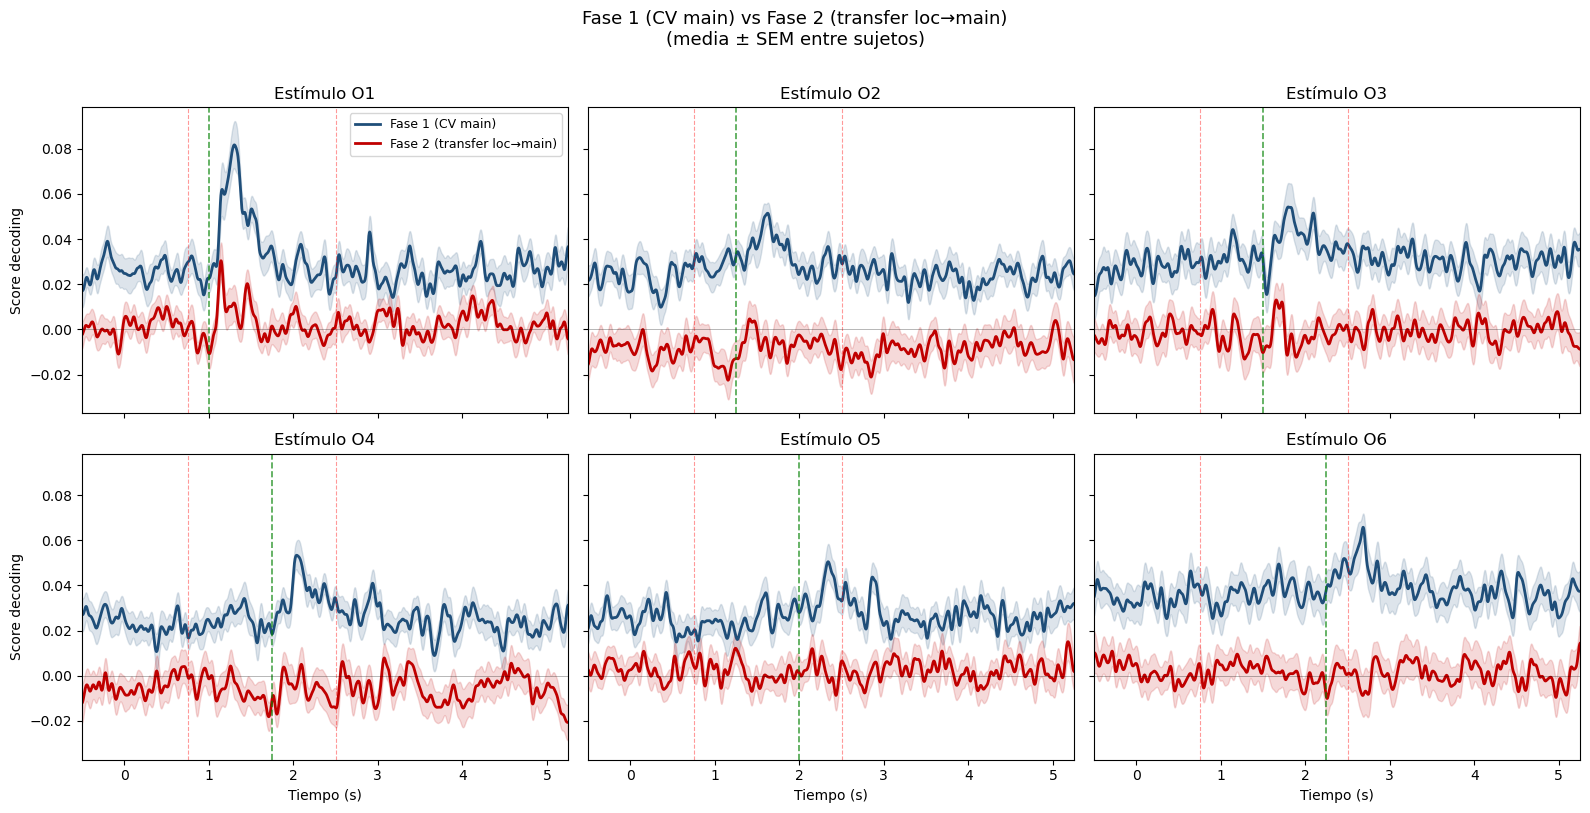

In [ ]:
# FASE 2 A = entrenamos en locstim (los piquitos del localizador) en el timepoint del pico (~0.13s) y testeamos en main en TODOS los timepoints

# encontrar el timepoint del pico en locstim (~0.13s)
time_loc    = all_locstim_epochs[0].times # es el vector de timepoints de locstim que va de −0.1s a +0.3s con 201 valores
peak_idx    = np.argmin(np.abs(time_loc - 0.13))  # timepoint mas cercano a 0.13s = que es el timpoint del pico mas informatimo que se ve en el grand average de locstim

print(f'timepoint del pico en locstim: {time_loc[peak_idx]:.3f}s (índice {peak_idx})')

# (n_sujetos × n_estímulos × n_timepoints_main)
scorer_transfer      = np.zeros((nSubj, n_stim, n_time))
all_preds_transfer   = {}

t_start = tm.time()

# para cada sujeto cogemos sus datos de EEG del localizador (Y_loc) y de la tarea principal (Y_main), y sus metadatas correspondientes (meta_loc, meta_main)
for isubj in range(nSubj):
    print(f'\nsujeto {subjs_ok[isubj]} ({isubj+1}/{nSubj}) ──')

    # datos locstim y main de este sujeto
    Y_loc      = all_locstim_rawdata[isubj]['epoch_dat']   # (n_locstim × 32 × 201)
    meta_loc   = all_locstim_rawdata[isubj]['metadata'].reset_index(drop=True)
    Y_main     = all_main_rawdata[isubj]['epoch_dat']      # (n_main × 32 × 2876)
    meta_main  = all_main_rawdata[isubj]['metadata'].reset_index(drop=True)

    all_preds_transfer[isubj] = {}

    # para cada estímulo, entrenamos el modelo con los trials del localizador que corresponden a ese estímulo (en el timepoint del pico) y testeamos en la tarea principal en todos los timepoints
    for i_stim, col in enumerate(stim_cols):
        stim_name = f'o{i_stim+1}'  # convertimos el numero a nombre de estimulo ('o1', 'o2'...)

        # TRAIN: locstim en el timepoint del pico 
        # cogemos solo los trials del locstim donde variable == 'o1' (o o2, o3...)
        idx_loc  = meta_loc[meta_loc['variable'] == stim_name].index.tolist() # busca en la metadata del localizador los trials que corresponden a ese estímulo (o1, o2, o3...) y devuelve sus índices
        X_train  = Y_loc[idx_loc, :, peak_idx]  # coge la actividad de EEG de esos trials en el timepoint del pico (shape: n_trials_locstim × 32)
        y_train  = np.array(meta_loc.loc[idx_loc, 'rads'], dtype=float) # coge las orientaciones reales (en radianes) de esos trials del localizador, que es lo que el modelo va a aprender a predecir

        # normalizamos
        scaler  = StandardScaler().fit(X_train)
        X_train = scaler.transform(X_train)

        # entrenamos con TODOS los trials del localizador
        clf = AngularRegression(clf=LinearSVR(max_iter=5000, C=0.1))
        clf.fit(X_train, y_train)

        # TEST: main en cada timepoint 
        y_test    = np.array(meta_main[col], dtype=float) # orientaciones reales de la tarea principal para ese estímulo (o1, o2, o3...)
        preds_all = np.full((Y_main.shape[0], n_time), np.nan) # array donde guardamos las predicciones del modelo para cada trial y cada timepoint de la tarea principal

        for it in range(n_time):
            X_test        = Y_main[:, :, it]  # coge la actividad de todos los trials de main en ese instante exacto
            X_test        = scaler.transform(X_test)   # normalizamos
            preds_all[:, it] = clf.predict(X_test) # hacemos la predicción de la orientación para cada trial de main en ese timepoint y guardamos las predicciones
 
        # score por timepoint
        for it in range(n_time):
            scorer_transfer[isubj, i_stim, it] = scorer_angle(y_test, preds_all[:, it]) # compara las orientaciones reales de main con las predicciones del clasificador entrenado en loc

        # guardamos predicciones 
        all_preds_transfer[isubj][i_stim] = preds_all.copy()

        print(f'  O{i_stim+1} ✓', end='', flush=True)

    elapsed = (tm.time() - t_start) / 60
    print(f'  → {elapsed:.1f} min transcurridos')

print(f'\nTransfer decoding completado — shape: {scorer_transfer.shape}')

# guardar 
import pickle

results_transfer = {
    'scorer_transfer':    scorer_transfer,
    'all_preds_transfer': all_preds_transfer,
    'time':               time,
    'subjs_ok':           subjs_ok,
    'stim_cols':          stim_cols,
}

save_path_transfer = '/Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EEG/decoding_results_transfer.pkl'
with open(save_path_transfer, 'wb') as f:
    pickle.dump(results_transfer, f)

print(f'resultados guardados en: {save_path_transfer}')

# plot — comparacion Fase 1 vs Fase 2 
from scipy.ndimage import gaussian_filter1d

sigma = 10
scorer_transfer_smooth = gaussian_filter1d(scorer_transfer, sigma=sigma, axis=2)
scorer_main_smooth     = gaussian_filter1d(scorer_all_subjs, sigma=sigma, axis=2)

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i_stim in range(n_stim):
    ax = axes[i_stim]

    # Fase 1 — cros validation dentro de main
    mean1 = np.mean(scorer_main_smooth[:, i_stim, :], axis=0)
    sem1  = np.std(scorer_main_smooth[:, i_stim, :], axis=0) / np.sqrt(nSubj)
    ax.plot(time, mean1, color='#1f4e79', lw=2, label='Fase 1 (CV main)')
    ax.fill_between(time, mean1 - sem1, mean1 + sem1, color='#1f4e79', alpha=0.15)

    # Fase 2 — transfer loc → main
    mean2 = np.mean(scorer_transfer_smooth[:, i_stim, :], axis=0)
    sem2  = np.std(scorer_transfer_smooth[:, i_stim, :], axis=0) / np.sqrt(nSubj)
    ax.plot(time, mean2, color='#c00000', lw=2, label='Fase 2 (transfer loc→main)')
    ax.fill_between(time, mean2 - sem2, mean2 + sem2, color='#c00000', alpha=0.15)

    t_onset = 0.75 + 0.25 * (i_stim + 1)
    ax.axvline(t_onset, color='green', ls='--', lw=1.2, alpha=0.7)
    ax.axvline(0.75,             color='red', ls='--', lw=0.8, alpha=0.4)
    ax.axvline(0.75 + 0.25 * 7, color='red', ls='--', lw=0.8, alpha=0.4)
    ax.axhline(0, color='black', ls='-', lw=0.5, alpha=0.4)

    ax.set_title(f'Estímulo O{i_stim+1}', fontsize=12)
    ax.set_xlim([time[0], time[-1]])
    if i_stim in [0, 3]:
        ax.set_ylabel('Score decoding', fontsize=10)
    if i_stim in [3, 4, 5]:
        ax.set_xlabel('Tiempo (s)', fontsize=10)
    if i_stim == 0:
        ax.legend(fontsize=9)

fig.suptitle('Fase 1 (CV main) vs Fase 2 (transfer loc→main)\n'
             '(media ± SEM entre sujetos)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


── Sujeto s01 (1/25) ──
  O1 ✓  O2 ✓  O3 ✓  O4 ✓  O5 ✓  O6 ✓  → 0.9 min transcurridos

── Sujeto s02 (2/25) ──
  O1 ✓  O2 ✓  O3 ✓  O4 ✓  O5 ✓  O6 ✓  → 1.9 min transcurridos

── Sujeto s03 (3/25) ──
  O1 ✓  O2 ✓  O3 ✓  O4 ✓  O5 ✓  O6 ✓  → 2.9 min transcurridos

── Sujeto s04 (4/25) ──
  O1 ✓  O2 ✓  O3 ✓  O4 ✓  O5 ✓  O6 ✓  → 3.7 min transcurridos

── Sujeto s05 (5/25) ──
  O1 ✓  O2 ✓  O3 ✓  O4 ✓  O5 ✓  O6 ✓  → 4.7 min transcurridos

── Sujeto s07 (6/25) ──
  O1 ✓  O2 ✓  O3 ✓  O4 ✓  O5 ✓  O6 ✓  → 5.7 min transcurridos

── Sujeto s08 (7/25) ──
  O1 ✓  O2 ✓  O3 ✓  O4 ✓  O5 ✓  O6 ✓  → 6.7 min transcurridos

── Sujeto s09 (8/25) ──
  O1 ✓  O2 ✓  O3 ✓  O4 ✓  O5 ✓  O6 ✓  → 7.6 min transcurridos

── Sujeto s10 (9/25) ──
  O1 ✓  O2 ✓  O3 ✓  O4 ✓  O5 ✓  O6 ✓  → 8.6 min transcurridos

── Sujeto s11 (10/25) ──
  O1 ✓  O2 ✓  O3 ✓  O4 ✓  O5 ✓  O6 ✓  → 9.6 min transcurridos

── Sujeto s12 (11/25) ──
  O1 ✓  O2 ✓  O3 ✓  O4 ✓  O5 ✓  O6 ✓  → 10.5 min transcurridos

── Sujeto s13 (12/25) ──
  O1 ✓  O2 ✓  

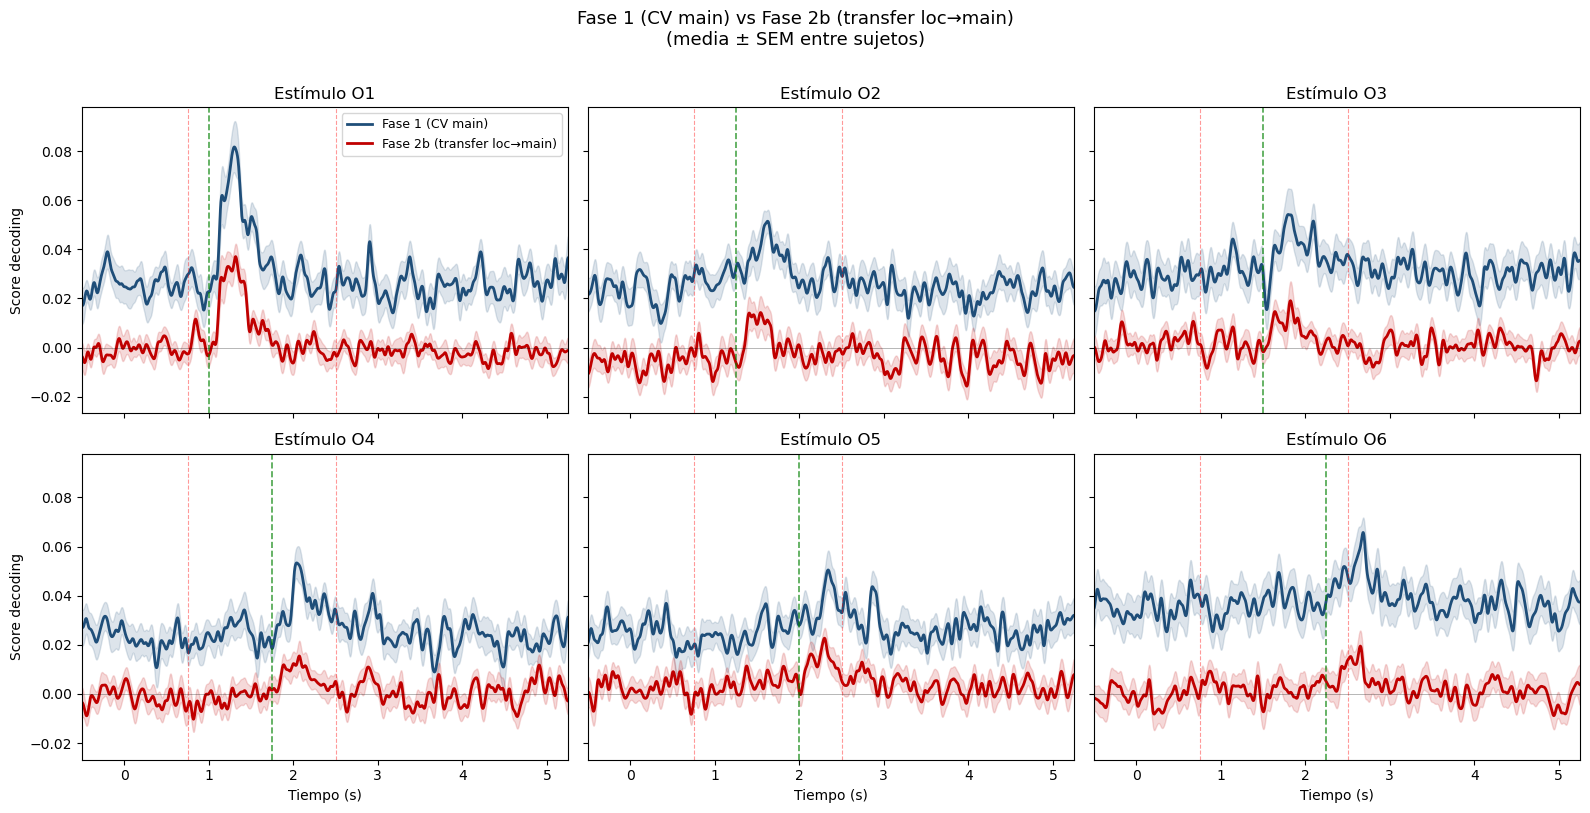

In [ ]:
# FASE 2 B : transfer decoding: TRAIN en loc_epo, TEST en main_epo (loc_epo y main_epo tienen la misma ventana temporal (−0.5s a +5.25s, 2876 timepoints)
# entrenamos en cada timepoint de loc y testeamos en el mismo timepoint de main

# (n_sujetos × n_estímulos × n_timepoints)
scorer_transfer2      = np.zeros((nSubj, n_stim, n_time))
all_preds_transfer2   = {}

t_start = tm.time()

# para cada sujeto cogemos sus datos de EEG del localizador (Y_loc) y de la tarea principal (Y_main), y sus metadatas correspondientes (meta_loc, meta_main)
for isubj in range(nSubj):
    print(f'\nsujeto {subjs_ok[isubj]} ({isubj+1}/{nSubj}) ──')

    Y_loc     = all_loc_rawdata[isubj]['epoch_dat']    # (n_loc × 32 × 2876)
    meta_loc  = all_loc_rawdata[isubj]['metadata'].reset_index(drop=True)
    Y_main    = all_main_rawdata[isubj]['epoch_dat']   # (n_main × 32 × 2876)
    meta_main = all_main_rawdata[isubj]['metadata'].reset_index(drop=True)

    all_preds_transfer2[isubj] = {}

    # para cada estímulo, entrenamos el modelo con los trials del localizador que corresponden a ese estímulo en cada timepoint y testeamos en la tarea principal en el mismo timepoint
    for i_stim, col in enumerate(stim_cols):

        y_train = np.array(meta_loc[col], dtype=float)   # orientaciones en loc
        y_test  = np.array(meta_main[col], dtype=float)  # orientaciones en main
        preds_all = np.full((Y_main.shape[0], n_time), np.nan) # array donde guardamos las predicciones del modelo para cada trial y cada timepoint de la tarea principal

        # para cada timepoint, entrenamos el modelo con los datos de EEG de loc en ese timepoint y testeamos en main en ese mismo timepoint
        for it in range(n_time):

            # TRAIN: loc en el timepoint it 
            X_train  = Y_loc[:, :, it]  # coge la actividad de loc en ese instante exacto (shape: n_trials_loc × 32)
            scaler   = StandardScaler().fit(X_train) # normalizamos con la media y desviacion estandar de loc
            X_train  = scaler.transform(X_train) # normalizamos los datos de EEG de loc para ese timepoint (media 0, desviacion estandar 1)

            clf = AngularRegression(clf=LinearSVR(max_iter=5000, C=0.1)) # definimos el clasificador que usaremos para predecir la orientación a partir de los datos de EEG. Es ANGULAREGRESION, una regresión lineal adaptada a datos circulares (orientaciones)
            clf.fit(X_train, y_train)

            # TEST: main en el mismo timepoint it 
            X_test        = Y_main[:, :, it]  # coge la actividad de main en el mismo instante
            X_test        = scaler.transform(X_test) # normalizamos main con la media y desviacion estandar de loc, para que el modelo pueda aplicar lo que ha aprendido en loc a main
            preds_all[:, it] = clf.predict(X_test) # hacemos la predicción de la orientación para cada trial de main en ese timepoint y guardamos las predicciones

        # score por timepoint
        for it in range(n_time):
            scorer_transfer2[isubj, i_stim, it] = scorer_angle( # comparamos las orientaciones reales de main con las predicciones del clasificador entrenado en loc para ese mismo timepoint
                y_test, preds_all[:, it]
            )

        all_preds_transfer2[isubj][i_stim] = preds_all.copy() # guardamos las predicciones para este sujeto y este estímulo
        print(f'  O{i_stim+1} ✓', end='', flush=True)

    elapsed = (tm.time() - t_start) / 60
    print(f'  → {elapsed:.1f} min transcurridos')

print(f'\ntransfer decoding 2b completado — shape: {scorer_transfer2.shape}')

# ── Guardar ───────────────────────────────────────────────────────────────────
import pickle

results_transfer2 = {
    'scorer_transfer2':    scorer_transfer2,
    'all_preds_transfer2': all_preds_transfer2,
    'time':                time,
    'subjs_ok':            subjs_ok,
    'stim_cols':           stim_cols,
}

save_path_transfer2 = '/Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EEG/decoding_results_transfer2.pkl'
with open(save_path_transfer2, 'wb') as f:
    pickle.dump(results_transfer2, f)

print(f'resultados guardados en: {save_path_transfer2}')

# plot — comparacoón Fase 1 vs Fase 2b 
from scipy.ndimage import gaussian_filter1d

sigma = 10
scorer_transfer2_smooth = gaussian_filter1d(scorer_transfer2, sigma=sigma, axis=2)
scorer_main_smooth      = gaussian_filter1d(scorer_all_subjs, sigma=sigma, axis=2)

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i_stim in range(n_stim):
    ax = axes[i_stim]

    mean1 = np.mean(scorer_main_smooth[:, i_stim, :], axis=0)
    sem1  = np.std(scorer_main_smooth[:, i_stim, :], axis=0) / np.sqrt(nSubj)
    ax.plot(time, mean1, color='#1f4e79', lw=2, label='Fase 1 (CV main)')
    ax.fill_between(time, mean1 - sem1, mean1 + sem1, color='#1f4e79', alpha=0.15)

    mean2 = np.mean(scorer_transfer2_smooth[:, i_stim, :], axis=0)
    sem2  = np.std(scorer_transfer2_smooth[:, i_stim, :], axis=0) / np.sqrt(nSubj)
    ax.plot(time, mean2, color='#c00000', lw=2, label='Fase 2b (transfer loc→main)')
    ax.fill_between(time, mean2 - sem2, mean2 + sem2, color='#c00000', alpha=0.15)

    t_onset = 0.75 + 0.25 * (i_stim + 1)
    ax.axvline(t_onset, color='green', ls='--', lw=1.2, alpha=0.7)
    ax.axvline(0.75,             color='red', ls='--', lw=0.8, alpha=0.4)
    ax.axvline(0.75 + 0.25 * 7, color='red', ls='--', lw=0.8, alpha=0.4)
    ax.axhline(0, color='black', ls='-', lw=0.5, alpha=0.4)

    ax.set_title(f'Estímulo O{i_stim+1}', fontsize=12)
    ax.set_xlim([time[0], time[-1]])
    if i_stim in [0, 3]:
        ax.set_ylabel('Score decoding', fontsize=10)
    if i_stim in [3, 4, 5]:
        ax.set_xlabel('Tiempo (s)', fontsize=10)
    if i_stim == 0:
        ax.legend(fontsize=9)

fig.suptitle('Fase 1 (CV main) vs Fase 2b (transfer loc→main)\n'
             '(media ± SEM entre sujetos)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()